# Lecture 2 — SARSA, Monte Carlo, and the Cost of Exploration

**Reinforcement Learning, 2025-26**

## Where we are

In Lecture 1 we built a tabular Q-learning agent and watched it solve a deterministic version of `MicrobeGridEnv`. The microbe found the cliff-edge optimal path and stayed on it — a clean victory, made possible by the fact that nothing the microbe did could ever go wrong: every commanded action was executed exactly as intended.

The world is rarely that obliging. Most environments — from a mobile robot on a real floor to a player in a card game to a trading agent in a noisy market — are **stochastic**: the same action in the same state can produce different outcomes. We will spend today understanding how stochasticity changes the picture, and we will meet two new families of model-free agents — **SARSA** and **Monte Carlo** — that handle the resulting uncertainty in qualitatively different ways from Q-learning.

## What you will learn today

By the end of this lecture you will be able to:

1. Distinguish **on-policy** from **off-policy** model-free control, and explain why the same observed transition produces different updates under SARSA and Q-learning.
2. Implement and train tabular **SARSA** and **Monte Carlo** agents (both first-visit and every-visit) using the same `Agent` interface and training loop introduced in Lecture 1.
3. Diagnose three model-free methods on the same problem — comparing their **learning curves**, their **learned policies**, and their **bias–variance trade-offs** — and reason about which method to choose in which regime.

## How we will get there

We open with a side-by-side comparison: Q-learning on the deterministic environment of Lecture 1, against Q-learning on a stochastic version of the same environment with `slippery = 0.2`. The contrast motivates the rest of the lecture, by exposing how the same algorithm behaves differently in the presence of irreducible noise. We then introduce SARSA as a small but consequential modification of Q-learning, train it on the stochastic environment, and compare the two agents directly. After a short break we introduce Monte Carlo control, contrasting it with the temporal-difference family along the bias–variance axis. We close by putting the three methods on a single grid and reading what they have learned.

The agents we build today live in `rlc/agents/sarsa.py` and `rlc/agents/monte_carlo.py`; the training loop, plotting helpers, and `MicrobeGridEnv` are reused unchanged from Lecture 1.

## Experimental setup

The lecture compares several agents on the same environment under controlled conditions. To keep the comparison fair and the notebook readable, all hyperparameters and environment configurations are gathered in the cell below — a single source of truth for everything that follows. The training schedule, the random seed, and the parameters of the three agents are defined once and reused throughout the notebook. Whenever you want to experiment with a different setting, this is the cell to edit.

We use a slightly larger habitat than in Lecture 1 — six rows instead of four — to give SARSA enough room to learn a visibly distinct trajectory from Q-learning. The toxic band still occupies the bottom row between start and goal, matching the standard Cliff Walking layout of Sutton & Barto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

from rlc.envs.microbe import MicrobeGridEnv
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train, evaluate
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

# ============================================================================
# Environment configurations
# ============================================================================
# A 6 x 12 habitat with a row of toxic cells along the bottom edge,
# between start (5, 0) and goal (5, 11). The deterministic and stochastic
# variants share everything except the slippery parameter.

_GRID_HEIGHT = 6
_GRID_WIDTH = 12
_TOXIC_CELLS = [(5, c) for c in range(1, 11)]
_START_POS = (5, 0)
_GOAL_POS = (5, 11)

ENV_DET = dict(
    height=_GRID_HEIGHT,
    width=_GRID_WIDTH,
    start_pos=_START_POS,
    goal_pos=_GOAL_POS,
    toxic_cells=_TOXIC_CELLS,
    slippery=0.0,
    render_mode="rgb_array",
)

ENV_SLIP = dict(
    height=_GRID_HEIGHT,
    width=_GRID_WIDTH,
    start_pos=_START_POS,
    goal_pos=_GOAL_POS,
    toxic_cells=_TOXIC_CELLS,
    slippery=0.2,
    render_mode="rgb_array",
)

# ============================================================================
# Training schedule
# ============================================================================
N_EPISODES = 1500
EVAL_EVERY = 50
EVAL_EPISODES = 20
MAX_STEPS_PER_EPISODE = 500
EVAL_MAX_STEPS = 500
MASTER_SEED = 42

# ============================================================================
# Agent hyperparameters
# ============================================================================
# Q-learning and SARSA share the same hyperparameter schedule, so that any
# difference observed in their behaviour can be attributed to the algorithm
# itself and not to incidental tuning.

_TD_PARAMS = dict(
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
)

Q_PARAMS = dict(_TD_PARAMS)
SARSA_PARAMS = dict(_TD_PARAMS)

# Monte Carlo (introduced later in the lecture). Parameters are placeholders
# here so that all configurations are visible in one place; the agent class
# is implemented in rlc/agents/monte_carlo.py.
MC_PARAMS = dict(
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
    every_visit=False,   # False = first-visit MC, True = every-visit MC
)

## Q-learning under uncertainty

Before introducing new algorithms, let us see what happens to the algorithm we already know when we add stochasticity to the environment. We train two Q-learning agents — one on the deterministic `MicrobeGridEnv` of Lecture 1, one on a stochastic version with `slippery = 0.2` — using identical hyperparameters and identical training schedules. The agents are otherwise indistinguishable; only the world they inhabit differs.

In [2]:
# Deterministic environment
env_q_det = MicrobeGridEnv(**ENV_DET)
eval_env_q_det = MicrobeGridEnv(**ENV_DET)
agent_q_det = QLearningAgent(
    n_states=env_q_det.observation_space.n,
    n_actions=env_q_det.action_space.n,
    seed=MASTER_SEED + 1,
    **Q_PARAMS,
)
hist_q_det = train(
    agent_q_det, env_q_det,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_q_det,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

# Stochastic environment (slippery = 0.2)
env_q_slip = MicrobeGridEnv(**ENV_SLIP)
eval_env_q_slip = MicrobeGridEnv(**ENV_SLIP)
agent_q_slip = QLearningAgent(
    n_states=env_q_slip.observation_space.n,
    n_actions=env_q_slip.action_space.n,
    seed=MASTER_SEED + 2,
    **Q_PARAMS,
)
hist_q_slip = train(
    agent_q_slip, env_q_slip,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_q_slip,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

print(f"Deterministic: final eval return = {hist_q_det.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_q_det.eval_std_returns[-1]:.1f})")
print(f"Slippery 0.2:  final eval return = {hist_q_slip.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_q_slip.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/1500 [00:00<?, ?ep/s]

Training:   0%|          | 0/1500 [00:00<?, ?ep/s]

Deterministic: final eval return =  -13.0  (std 0.0)
Slippery 0.2:  final eval return =  -30.6  (std 11.9)


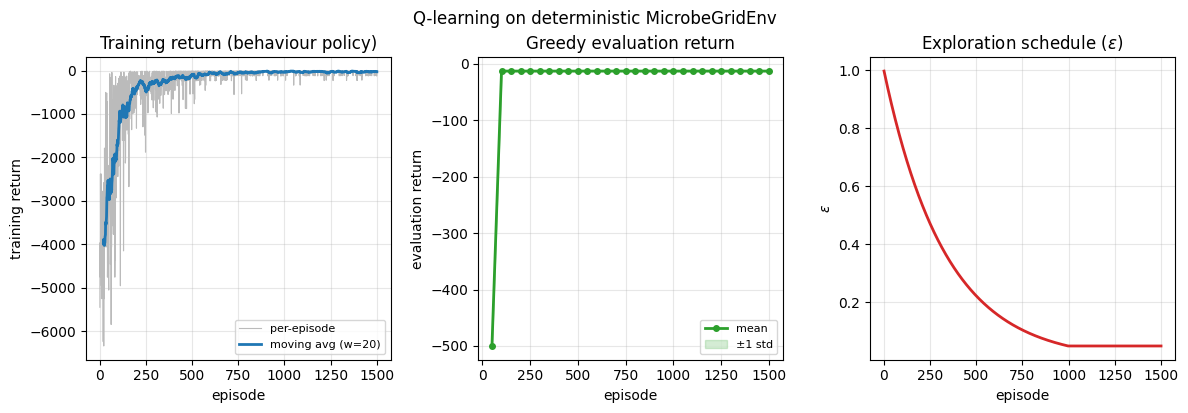

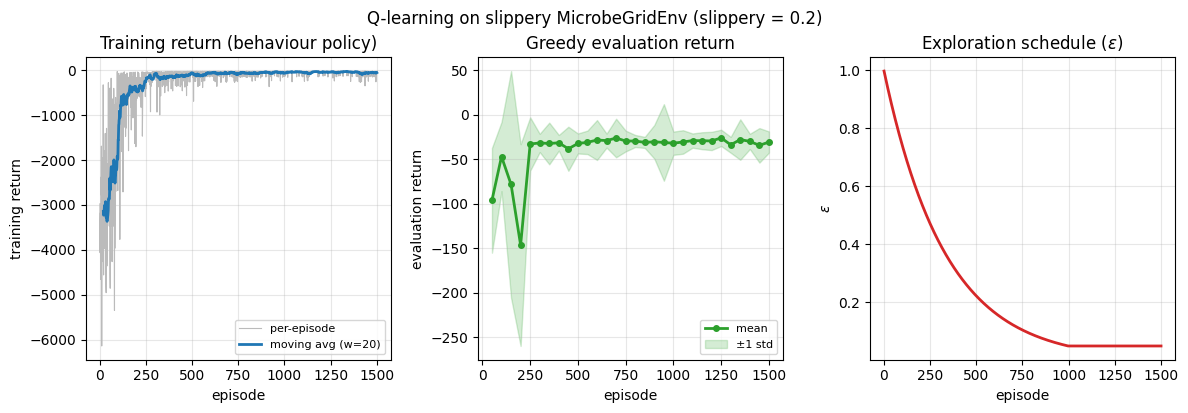

In [3]:
fig_det = plot_learning_curves(hist_q_det)
fig_det.suptitle("Q-learning on deterministic MicrobeGridEnv", y=1.02)
plt.show()

fig_slip = plot_learning_curves(hist_q_slip)
fig_slip.suptitle("Q-learning on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

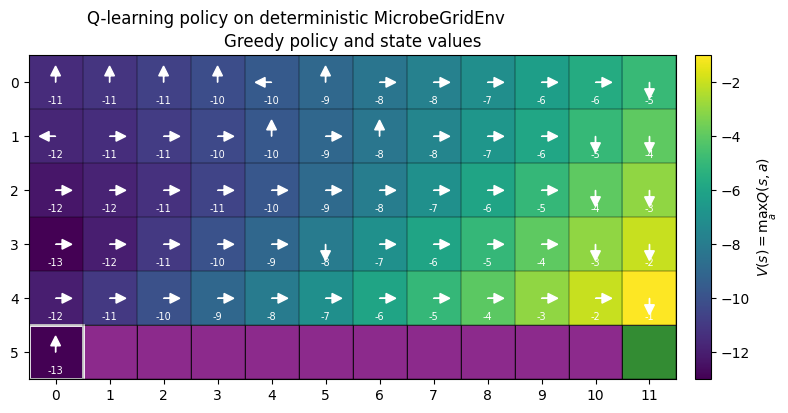

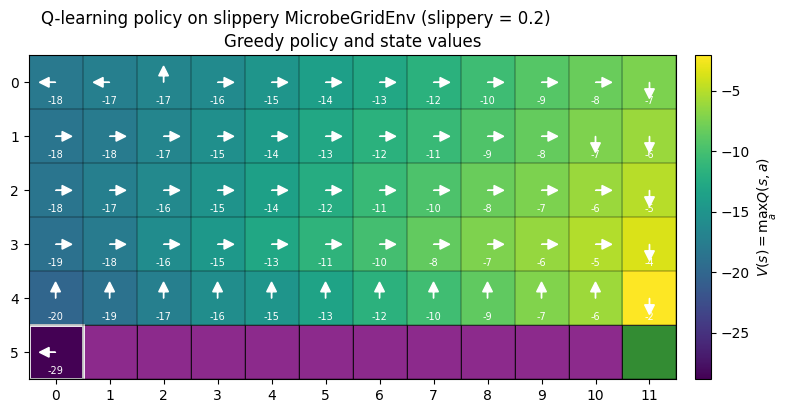

In [5]:
fig_pol_det = plot_grid_policy_and_values(agent_q_det, env_q_det, annotate_values=True)
fig_pol_det.suptitle("Q-learning policy on deterministic MicrobeGridEnv", y=1.02)
plt.show()

fig_pol_slip = plot_grid_policy_and_values(agent_q_slip, env_q_slip, annotate_values=True)
fig_pol_slip.suptitle("Q-learning policy on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

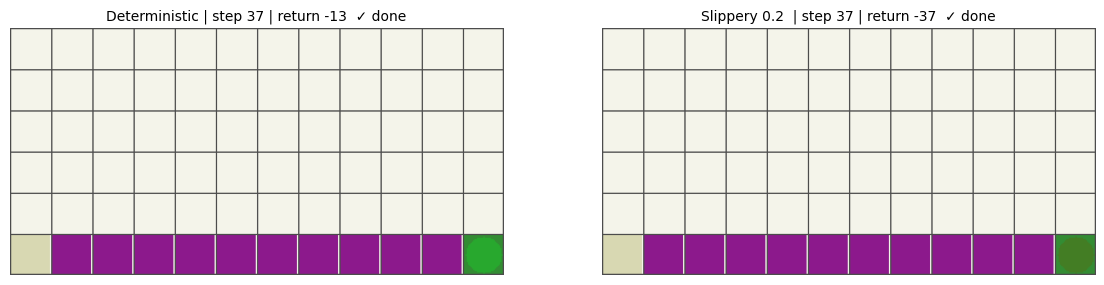

Deterministic episode: return = -13
Slippery episode:      return = -37


In [6]:
def show_two_frames(frame_left, title_left, frame_right, title_right):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(frame_left)
    axes[0].axis("off")
    axes[0].set_title(title_left, fontsize=10)
    axes[1].imshow(frame_right)
    axes[1].axis("off")
    axes[1].set_title(title_right, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
ROLLOUT_MAX_STEPS = 60

env_left = MicrobeGridEnv(**ENV_DET)
env_right = MicrobeGridEnv(**ENV_SLIP)

obs_l, _ = env_left.reset(seed=MASTER_SEED + 100)
obs_r, _ = env_right.reset(seed=MASTER_SEED + 100)
ret_l, ret_r = 0.0, 0.0
done_l, done_r = False, False
step = 0

show_two_frames(
    env_left.render(),
    f"Deterministic | step 0 | return 0",
    env_right.render(),
    f"Slippery 0.2  | step 0 | return 0",
)
time.sleep(FRAME_DELAY)

for _ in range(ROLLOUT_MAX_STEPS):
    if not done_l:
        a_l = agent_q_det.select_action(obs_l, greedy=True)
        obs_l, r_l, term_l, trunc_l, _ = env_left.step(a_l)
        ret_l += r_l
        done_l = term_l or trunc_l
    if not done_r:
        a_r = agent_q_slip.select_action(obs_r, greedy=True)
        obs_r, r_r, term_r, trunc_r, _ = env_right.step(a_r)
        ret_r += r_r
        done_r = term_r or trunc_r

    step += 1
    clear_output(wait=True)
    show_two_frames(
        env_left.render(),
        f"Deterministic | step {step} | return {ret_l:.0f}"
        + ("  ✓ done" if done_l else ""),
        env_right.render(),
        f"Slippery 0.2  | step {step} | return {ret_r:.0f}"
        + ("  ✓ done" if done_r else ""),
    )
    time.sleep(FRAME_DELAY)

    if done_l and done_r:
        break

env_left.close()
env_right.close()

print(f"Deterministic episode: return = {ret_l:.0f}")
print(f"Slippery episode:      return = {ret_r:.0f}")

The animation makes the abstract observation concrete. The deterministic microbe walks the cliff edge with the calm confidence of a system that knows the world will obey it. The slippery one walks the same cliff edge — same policy, same arrows on the grid — and pays a price every few episodes when the world reminds it that it does not. Q-learning has no language to express this difference: its target asks "what is the value of the greedy action at the next state?" and the answer is the same in both worlds, ignoring the noise that the agent is about to be pushed through.

The next section introduces an algorithm that tells a different story. SARSA's target asks instead "what is the value of the action the agent will *actually* take next?" — and that single change in the question changes the answer.